In [ ]:
# 02_harmonization.ipynb
# Goal of this notebook:
# - Attach scanner/vendor information to your radiomics feature table
# - Explore vendor-specific "batch effects" in feature space
# - Apply ComBat harmonization to reduce vendor effects
# - Quantify and visualize how stability changes before vs after harmonization
#
# You should:
# - Understand where features come from (01_exploration) and where vendor info comes from (JSON sidecars)
# - Be able to run the key helper functions
# - Decide when to use raw vs harmonized features later in the project

In [2]:
!pip install neuroCombat

Defaulting to user installation because normal site-packages is not writeable


***

## 0. Setup, imports, and paths

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from neuroCombat import neuroCombat

# plotting style
sns.set(style="whitegrid")

PROJECT_ROOT = Path.home() / "Imaging en AI vak"

DATAROOT = PROJECT_ROOT / "data"
RAWROOT = DATAROOT / "raw" / "ISLES-2022"
PROCROOT = DATAROOT / "processed"
RESULTS = PROCROOT
features_file = PROCROOT / "features_raw.csv"

print(features_file)

/home/jovyan/Imaging en AI vak/data/processed/features_raw.csv


In [4]:
#Check if features_raw.csv exists
if features_file.is_file():
    print(f"features_raw.csv found: {features_file}")
else:
    print(f"features_raw.csv NOT found! Make sure you ran notebook 01.")

# Check if ISLES-2022 raw data folder exists and is not empty
if RAWROOT.is_dir():
    all_files = list(RAWROOT.rglob("*"))  # recursive list of all files
    if all_files:
        print(f"ISLES-2022 folder exists and contains files ({len(all_files)} total).")
        
        # Optional: check for JSON sidecars for DWI images
        json_files = list(RAWROOT.rglob("*DWI*.json"))
        if json_files:
            print(f"DWI JSON sidecars found: {len(json_files)} files")
        else:
            print("No DWI JSON sidecars found!")
    else:
        print("ISLES-2022 folder is empty!")
else:
    print("ISLES-2022 folder does NOT exist!")

features_raw.csv found: /home/jovyan/Imaging en AI vak/data/processed/features_raw.csv
ISLES-2022 folder exists and contains files (2095 total).
DWI JSON sidecars found: 2 files


**Student direction:**

- Make sure `data/processed/features_raw.csv` from notebook 01 exists.
- Make sure `data/raw/ISLES-2022` contains the original ISLES dataset with JSON sidecars for DWI.

***

## 1. Load radiomics features and choose which ones to analyze

In this notebook we typically focus on a subset of “good” radiomic features (e.g. the top 20 most stable ones from center‑stability analysis). If you don’t have that yet, you can temporarily work with **all** features, but the code is written to highlight a subset.

In [5]:
# Load full radiomics features table
features_file = PROCROOT / "features_raw.csv"
if not features_file.is_file():
    raise FileNotFoundError(f"{features_file} not found. Make sure notebook 01 has been run.")

features_df = pd.read_csv(features_file)
print("Features loaded:", features_df.shape)

# Select features to analyze. Path to top 20 features CSV (if available)
top20_path = RESULTS / "top20_features.csv"

if top20_path.exists():
    # Load top 20 feature names
    top_20_features = pd.read_csv(top20_path)
    feature_names = top_20_features["feature_name"].tolist()
else:
    # Fallback: pick first 20 columns starting with "original"
    feature_names = [c for c in features_df.columns if c.startswith("original")][:20]

print("Number of selected features:", len(feature_names))
print("First selected features:", feature_names[:5])

# Identify subject ID column. Inspect features_df.columns if unsure
ID_COL = "caseid"
if ID_COL not in features_df.columns:
    raise ValueError(f"ID column '{ID_COL}' not found in features_df.columns")

# Sanity check: ensure all selected features exist
missing_features = [f for f in feature_names if f not in features_df.columns]
if missing_features:
    print("Warning: the following selected features are missing:", missing_features)
else:
    print("All selected features exist in the DataFrame.")

# Create clean DataFrame with subject IDs and selected features
selected_df = features_df[[ID_COL] + feature_names]
print(selected_df.head())

features_df["subject_id_norm"] = features_df[ID_COL] #to prevent merge issues later in the code

Features loaded: (93, 106)
Number of selected features: 20
First selected features: ['original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn']
All selected features exist in the DataFrame.
               caseid  original_shape_Elongation  original_shape_Flatness  \
0  sub-strokecase0001                   0.999699                 0.648623   
1  sub-strokecase0003                   0.999428                 0.639477   
2  sub-strokecase0005                   0.999613                 0.639548   
3  sub-strokecase0007                   0.999513                 0.648777   
4  sub-strokecase0009                   0.999900                 0.648690   

   original_shape_LeastAxisLength  original_shape_MajorAxisLength  \
0                      166.112204                      256.099830   
1                      163.905093                      256.311282   
2                      163.882208

In this step the radiomics feature table generated in Notebook 01 was loaded from features_raw.csv. Non-feature columns such as subject identifiers and image references were removed to isolate the radiomics descriptors. The remaining columns represent radiomics features extracted with PyRadiomics, including intensity histogram statistics (first-order features), shape descriptors, and texture features such as GLCM. The selected features were stored as a numerical feature matrix, where each row represents a subject and each column represents a radiomics feature. This tabular representation allows further analysis of feature stability and scanner-related variability.

**Student direction:**

- Inspect `features_df.columns` and set `ID_COL` correctly.
- Make sure `feature_names` actually exist in `features_df`. If not, adjust.

***

## 2. Collect vendor metadata from ISLES JSON sidecars

This function reads scanner/vendor information from the DWI JSON files. You do not need to modify it; just understand its inputs/outputs:

- Input: `RAWROOT` (`data/raw`) where ISLES is stored.
- Output: `df_meta` with one row per subject: `subject_id`, `manufacturer`, `model`, `field_strength`.

In [6]:
import json
import pandas as pd
from pathlib import Path
from typing import Union #import the right libraries for read JSON metadata, work with tables, navigate directories

# Find all JSON sidecar files in the dataset
json_files = list(RAWROOT.rglob("*dwi.json"))
print("Number of JSON files found:", len(json_files))
json_files[:5]

def collect_isles_vendor_metadata(raw_root: Union[str, Path]) -> pd.DataFrame:
    """
    Traverse the ISLES-2022 directory, find DWI images and their JSON sidecars,
    and collect scanner/vendor metadata (manufacturer, model, field strength).

    Returns a DataFrame with:
        subject_id
        manufacturer
        model
        field_strength
    """

    raw_root = Path(raw_root)

    if not raw_root.exists():
        raise FileNotFoundError(f"data/raw directory not found: {raw_root}")

    # Locate ISLES dataset
    isles_root = raw_root / "ISLES-2022"
    if not isles_root.exists():
        isles_root = raw_root

    # Find subject folders
    case_dirs = sorted(
        d for d in isles_root.iterdir()
        if d.is_dir() and d.name.startswith("sub-strokecase")
    )

    rows = []
    n_missing_json = 0

    for sub_dir in case_dirs:

        sub_id = sub_dir.name
        ses_dir = sub_dir / "ses-0001"

        if not ses_dir.exists():
            continue

        dwi_dir = ses_dir / "dwi"

        if not dwi_dir.exists():
            continue

        dwi_nii = None

        # Prefer *_dwi.nii.gz
        candidates = sorted(dwi_dir.glob("*dwi.nii.gz"))

        if candidates:
            dwi_nii = candidates[0]

        else:
            candidates = sorted(
                p for p in dwi_dir.glob("*.nii.gz")
                if "adc" not in p.name.lower()
            )

            if candidates:
                dwi_nii = candidates[0]

        if dwi_nii is None:
            continue

        # Find matching JSON sidecar
        dwi_json = Path(str(dwi_nii).replace(".nii.gz", ".json"))

        if not dwi_json.exists():

            alt_json = dwi_nii.with_suffix(".json")

            if alt_json.exists():
                dwi_json = alt_json
            else:
                n_missing_json += 1
                continue

        # Load JSON metadata
        try:
            with open(dwi_json, "r") as f:
                meta = json.load(f)
        except Exception:
            continue

        manufacturer = (
            meta.get("Manufacturer")
            or meta.get("manufacturer")
            or "Unknown"
        )

        model = (
            meta.get("ManufacturersModelName")
            or meta.get("ManufacturerModelName")
            or meta.get("manufacturer_model")
            or "Unknown"
        )

        field_strength = (
            meta.get("MagneticFieldStrength")
            or meta.get("magnetic_field_strength")
        )

        rows.append(
            {
                "subject_id": sub_id,
                "manufacturer": manufacturer,
                "model": model,
                "field_strength": field_strength,
            }
        )

    if n_missing_json > 0:
        print(f"[INFO] Skipped {n_missing_json} subjects with no DWI JSON sidecar.")

    if not rows:
        print("No vendor metadata collected.")
        return pd.DataFrame()

    df_meta = pd.DataFrame(rows).drop_duplicates("subject_id")

    print("df_meta head:\n", df_meta.head())
    print("\nManufacturers:\n", df_meta["manufacturer"].value_counts())

    return df_meta

Number of JSON files found: 70


In [7]:
df_meta = collect_isles_vendor_metadata(RAWROOT)

[INFO] Skipped 55 subjects with no DWI JSON sidecar.
df_meta head:
            subject_id             manufacturer            model  \
0  sub-strokecase0001  Philips Medical Systems  Achieva dStream   
1  sub-strokecase0003  Philips Medical Systems  Achieva dStream   
2  sub-strokecase0005  Philips Medical Systems  Achieva dStream   
3  sub-strokecase0007  Philips Medical Systems  Achieva dStream   
4  sub-strokecase0009  Philips Medical Systems  Achieva dStream   

   field_strength  
0             3.0  
1             3.0  
2             3.0  
3             3.0  
4             3.0  

Manufacturers:
 manufacturer
Philips Medical Systems    61
Unknown                     8
SIEMENS                     1
Name: count, dtype: int64


In [8]:
out_path = PROCROOT
out_path.mkdir(parents=True, exist_ok=True)
vendor_file = out_path / "vendors.csv"
df_meta.to_csv(vendor_file, index=False)
print("Saved vendor metadata to:", vendor_file)

Saved vendor metadata to: /home/jovyan/Imaging en AI vak/data/processed/vendors.csv


In [9]:
print("Radiomics subjects:", features_df.shape[0])
print("Vendor metadata subjects:", df_meta.shape[0])

Radiomics subjects: 93
Vendor metadata subjects: 70


**Student direction:**

- Create `df_meta = collect_isles_vendor_metadata(RAWROOT)`.
- Save it once to disk so later notebooks can reuse it:

In [ ]:
# PSEUDOCODE:
# out_path = PROCROOT
# out_path.mkdir(parents=True, exist_ok=True)
# vendor_file = out_path / "vendors.csv"
# df_meta.to_csv(vendor_file, index=False)
# print("Saved vendor metadata to:", vendor_file)

In this step scanner metadata was extracted from the JSON sidecar files of the ISLES-2022 dataset. The JSON files associated with the DWI images contain acquisition parameters such as the scanner manufacturer, scanner model, and magnetic field strength. These metadata were parsed and stored in a tabular DataFrame indexed by subject identifier. Duplicate entries were removed to ensure one metadata record per subject. The resulting metadata table provides vendor information that will later be merged with the radiomics feature table to analyze between-center variability and scanner-related batch effects.

***

## 3. Align IDs between radiomics features and vendor metadata

Features and vendor metadata may use slightly different ID formats. This helper converts various formats into the standard ISLES subject ID.

In [10]:
def to_isles_id(x: str) -> str:
    """
    Normalize different ID formats to ISLES-style 'sub-strokecaseXXXX'.

    Examples:
      "sub-strokecase0001" -> "sub-strokecase0001"  (unchanged)
      "strokecase0001"     -> "sub-strokecase0001"
      "1"                  -> "sub-strokecase0001"
    """
    x = str(x)
    if x.startswith("sub-"):
        return x
    if x.startswith("strokecase"):
        return "sub-" + x
    if x.isdigit():
        return f"sub-strokecase{int(x):04d}"
    return x

In [11]:
ID_COL = "caseid"  # replace with your actual ID column in features_df

# Normalize features_df IDs
features_df["subject_id_norm"] = features_df[ID_COL].apply(to_isles_id)

# Normalize df_meta IDs
df_meta["subject_id_norm"] = df_meta["subject_id"].apply(to_isles_id)

# Optional: check examples
print("Example normalized IDs in features_df:")
print(features_df["subject_id_norm"].head().tolist())

print("Example normalized IDs in df_meta:")
print(df_meta["subject_id_norm"].head().tolist())

Example normalized IDs in features_df:
['sub-strokecase0001', 'sub-strokecase0003', 'sub-strokecase0005', 'sub-strokecase0007', 'sub-strokecase0009']
Example normalized IDs in df_meta:
['sub-strokecase0001', 'sub-strokecase0003', 'sub-strokecase0005', 'sub-strokecase0007', 'sub-strokecase0009']


In [12]:
# Identify common subjects
radiomics_ids = set(features_df["subject_id_norm"])
metadata_ids = set(df_meta["subject_id_norm"])
common_ids = radiomics_ids.intersection(metadata_ids)

# Filter to common subjects
features_aligned = features_df[features_df["subject_id_norm"].isin(common_ids)].copy()
meta_aligned = df_meta[df_meta["subject_id_norm"].isin(common_ids)].copy()

# Merge
merged_df = features_aligned.merge(
    meta_aligned,
    on="subject_id_norm",
    how="left"
)

print("Merged dataset shape:", merged_df.shape)
print("Subjects with missing vendor metadata:", merged_df["manufacturer"].isna().sum())

Merged dataset shape: (68, 111)
Subjects with missing vendor metadata: 0


In [13]:
aligned_file = PROCROOT / "radiomics_with_vendor_metadata.csv"
merged_df.to_csv(aligned_file, index=False)
print("Saved merged dataset to:", aligned_file)

Saved merged dataset to: /home/jovyan/Imaging en AI vak/data/processed/radiomics_with_vendor_metadata.csv


In Assignment 3, the main task was to align radiomics feature data with corresponding vendor metadata for ISLES subjects. First, a helper function to_isles_id was implemented to normalize subject IDs from different formats (e.g., numeric IDs, strokecaseXXXX, or already ISLES-style sub-strokecaseXXXX) into a consistent standard. This normalization was applied to both the features dataframe (features_df) and the metadata dataframe (df_meta), creating a new column subject_id_norm in each. After normalization, the sets of IDs were compared to identify common subjects, and only those subjects present in both datasets were retained. Finally, the aligned datasets were merged using the normalized IDs, producing a single dataframe that combined radiomics features with vendor information such as manufacturer, model, and field strength. The merge was verified to ensure no subjects were missing vendor metadata, and the resulting dataset was saved for further analysis. This workflow ensured consistent, accurate ID mapping and integration of imaging features with vendor information.

**Student direction:**

- Add a normalized ID column to `features_df`:

In [14]:
# PSEUDOCODE:
features_df["subject_id_norm"] = features_df[ID_COL].apply(to_isles_id)
print("Example normalized IDs:")
print(features_df["subject_id_norm"].head().tolist())
print("Example df_meta IDs:")
print(df_meta["subject_id"].head().tolist())

Example normalized IDs:
['sub-strokecase0001', 'sub-strokecase0003', 'sub-strokecase0005', 'sub-strokecase0007', 'sub-strokecase0009']
Example df_meta IDs:
['sub-strokecase0001', 'sub-strokecase0003', 'sub-strokecase0005', 'sub-strokecase0007', 'sub-strokecase0009']


- Rename `df_meta["subject_id"]` to `subject_id_norm` and merge:

In [15]:
print("Example radiomics IDs:")
print(features_df["subject_id_norm"].head())

print("\nExample vendor IDs:")
print(df_meta["subject_id_norm"].head())

radiomics_ids = set(features_df["subject_id_norm"])
metadata_ids = set(df_meta["subject_id_norm"])

common_ids = radiomics_ids.intersection(metadata_ids)

print("Radiomics subjects:", len(radiomics_ids))
print("Metadata subjects:", len(metadata_ids))
print("Common subjects:", len(common_ids))

features_aligned = features_df[
    features_df["subject_id_norm"].isin(common_ids)
].copy()

meta_aligned = df_meta[
    df_meta["subject_id_norm"].isin(common_ids)
].copy()

merged_df = features_aligned.merge(
    meta_aligned,
    on="subject_id_norm",
    how="left"
)
print("Merged dataset shape:", merged_df.shape)

merged_df[
    [ID_COL, "manufacturer", "model", "field_strength"]
].head()
aligned_file = PROCROOT / "radiomics_with_vendor_metadata.csv"

merged_df.to_csv(aligned_file, index=False)

print("Saved merged dataset to:", aligned_file)
missing_vendor = merged_df["manufacturer"].isna().sum()
print("Subjects with missing vendor metadata:", missing_vendor)

Example radiomics IDs:
0    sub-strokecase0001
1    sub-strokecase0003
2    sub-strokecase0005
3    sub-strokecase0007
4    sub-strokecase0009
Name: caseid, dtype: object

Example vendor IDs:
0    sub-strokecase0001
1    sub-strokecase0003
2    sub-strokecase0005
3    sub-strokecase0007
4    sub-strokecase0009
Name: subject_id, dtype: object
Radiomics subjects: 93
Metadata subjects: 70
Common subjects: 68
Merged dataset shape: (68, 112)
Saved merged dataset to: /home/jovyan/Imaging en AI vak/data/processed/radiomics_with_vendor_metadata.csv
Subjects with missing vendor metadata: 0


In [16]:
df_meta = df_meta.loc[:, ~df_meta.columns.duplicated()]
print(features_df.columns)
print(df_meta.columns)

Index(['caseid', 'original_shape_Elongation', 'original_shape_Flatness',
       'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength',
       'original_shape_Maximum2DDiameterColumn',
       'original_shape_Maximum2DDiameterRow',
       'original_shape_Maximum2DDiameterSlice',
       'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume',
       ...
       'original_gldm_LowGrayLevelEmphasis',
       'original_gldm_SmallDependenceEmphasis',
       'original_gldm_SmallDependenceHighGrayLevelEmphasis',
       'original_gldm_SmallDependenceLowGrayLevelEmphasis',
       'original_ngtdm_Busyness', 'original_ngtdm_Coarseness',
       'original_ngtdm_Complexity', 'original_ngtdm_Contrast',
       'original_ngtdm_Strength', 'subject_id_norm'],
      dtype='object', length=107)
Index(['subject_id', 'manufacturer', 'model', 'field_strength',
       'subject_id_norm'],
      dtype='object')


In [18]:
df_meta = df_meta.loc[:, ~df_meta.columns.duplicated()] # remove duplicates
# Drop original subject_id column since subject_id_norm already exists
df_meta = df_meta.drop(columns=["subject_id"], errors="ignore")
merged = features_df.merge(df_meta, on="subject_id_norm", how="inner")
print("Merged dataset shape:", merged.shape)
print("Vendors in merged dataset:")
print(merged["manufacturer"].value_counts())
print(merged.head())

Merged dataset shape: (68, 110)
Vendors in merged dataset:
manufacturer
Philips Medical Systems    61
Unknown                     7
Name: count, dtype: int64
               caseid  original_shape_Elongation  original_shape_Flatness  \
0  sub-strokecase0001                   0.999699                 0.648623   
1  sub-strokecase0003                   0.999428                 0.639477   
2  sub-strokecase0005                   0.999613                 0.639548   
3  sub-strokecase0007                   0.999513                 0.648777   
4  sub-strokecase0009                   0.999900                 0.648690   

   original_shape_LeastAxisLength  original_shape_MajorAxisLength  \
0                      166.112204                      256.099830   
1                      163.905093                      256.311282   
2                      163.882208                      256.246986   
3                      165.827457                      255.600102   
4                      166.089059 

At this point, `merged` should have:

- One row per subject with:
    - Columns in `feature_names` (radiomics).
    - `manufacturer`, `model`, `field_strength`.

***

## 4. Build matrices for ComBat and filter vendors

We now prepare the feature matrix and vendor labels in a form suitable for ComBat and later stability analysis.

In [19]:
# Extract radiomics features
X_raw = merged[feature_names].values

# Extract batch variable (scanner vendor)
batch_vendor = merged["manufacturer"].values

# Extract subject IDs
subject_ids = merged["subject_id_norm"].values

In [20]:
# Check 1: Verify there is one row per subject
is_unique = merged["subject_id_norm"].is_unique

print("One row per subject:", is_unique)
print("Unique subjects:", merged["subject_id_norm"].nunique())
print("Total rows:", len(merged))


# Check 2: Verify that all selected radiomics features exist
missing_features = [f for f in feature_names if f not in merged.columns]

if not missing_features:
    print("All selected radiomics features exist in the dataset.")
else:
    print("Missing features:", missing_features)


# Check 3: Verify metadata columns exist
required_meta = ["manufacturer", "model", "field_strength"]

missing_meta = [m for m in required_meta if m not in merged.columns]

if not missing_meta:
    print("Metadata columns present: manufacturer, model, field_strength")
else:
    print("Missing metadata columns:", missing_meta)

One row per subject: True
Unique subjects: 68
Total rows: 68
All selected radiomics features exist in the dataset.
Metadata columns present: manufacturer, model, field_strength


We set the minimum number of subjects per vendor to 5. ComBat requires a sufficient number of samples per batch
(scanner/vendor) to estimate batch-specific mean and variance. Vendors with fewer than 5 subjects would lead to unstable. harmonization parameters and unreliable correction. Therefore vendors with <5 subjects are excluded.

In [21]:
# Convert the merged dataframe to numpy arrays-> miss aanpassen naar 2
min_subjects_per_vendor = 5
batch_vendor_series = pd.Series(batch_vendor)
batch_counts = batch_vendor_series.value_counts()
valid_batches = batch_counts[batch_counts >= min_subjects_per_vendor].index
mask = batch_vendor_series.isin(valid_batches)

X_raw_valid = X_raw[mask]
batch_valid = batch_vendor_series[mask]
subject_ids_valid = subject_ids[mask]

print(f"Original n_samples: {X_raw.shape[0]}")
print(f"Valid n_samples after filtering vendors >= {min_subjects_per_vendor} subjects: {X_raw_valid.shape[0]}")
print("Valid vendors:\n", batch_valid.value_counts())

Original n_samples: 68
Valid n_samples after filtering vendors >= 5 subjects: 68
Valid vendors:
 Philips Medical Systems    61
Unknown                     7
Name: count, dtype: int64


**Student direction:**

- Make sure `feature_names` matches columns in `merged`.
- Decide a minimum number of subjects per vendor and document your choice.

***

## 5. Simulate vendor‑specific batch effects (educational step)

To clearly see how batch effects look, we add artificial shifts to some features per vendor.

In [22]:
import numpy as np
import pandas as pd

def inject_synthetic_vendor_offsets(
    X: np.ndarray,
    batch_series: pd.Series,
    feature_indices: list[int],
    vendor_shifts: dict[str, float]
) -> np.ndarray:
    """
    Create a copy of X and add vendor-specific offsets to selected features.

    Args:
        X: (n_samples, n_features) feature matrix
        batch_series: pandas Series of length n_samples with vendor labels
        feature_indices: list of feature indices to corrupt (e.g. first 5 features)
        vendor_shifts: dict mapping vendor name -> constant shift

    Returns:
        X_corrupted: same shape as X, with offsets injected
    """
    X_corrupted = X.copy()
    
    for vendor, shift in vendor_shifts.items():
        mask_vendor = batch_series == vendor
        if not mask_vendor.any():
            continue
        # Add the constant shift to the chosen features
        X_corrupted[np.ix_(mask_vendor.to_numpy(), feature_indices)] += shift
    
    return X_corrupted

In [23]:
# Example: corrupt the first 5 features
features_to_corrupt = list(range(5))  # indices 0,1,2,3,4
print("Features to corrupt (indices):", features_to_corrupt)
print("Feature names:", [feature_names[i] for i in features_to_corrupt])

Features to corrupt (indices): [0, 1, 2, 3, 4]
Feature names: ['original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn']


In [24]:
vendor_shifts = {
    "Philips Medical Systems": 0.8,
    "SIEMENS": -0.5,
    "Unknown": 0.3
}

In [25]:
X_raw_corrupted = inject_synthetic_vendor_offsets(
    X=X_raw_valid,
    batch_series=batch_valid,
    feature_indices=features_to_corrupt,
    vendor_shifts=vendor_shifts
)

print("X_raw_corrupted shape:", X_raw_corrupted.shape)

X_raw_corrupted shape: (68, 20)


We applied PCA to the corrupted dataset and plotted the first two principal components. Samples were colored by vendor to visualize clustering due to batch effects.
Observation: Distinct clusters by vendor, confirming that synthetic shifts introduced batch effects.

**Student direction:**

- Decide which features to “corrupt” (e.g. first 5 in `feature_names`).
- Decide shift values per vendor (e.g. `{ "Philips Medical Systems": 0.8, "SIEMENS": -0.5, "Unknown": 0.3 }`).
- Call `inject_synthetic_vendor_offsets` to create `X_raw_corrupted`.

You will **not** overwrite the original `X_raw`; keep both.

***

## 6. Apply ComBat harmonization

Here we run ComBat on the **corrupted** data to remove vendor‑specific mean/variance differences.

In [26]:
def run_combat(X: np.ndarray, batch: pd.Series) -> np.ndarray:
    """
    Apply ComBat harmonization to X with batch labels in 'batch'.

    Args:
        X: (n_samples, n_features) matrix (corrupted data)
        batch: pandas Series of vendor labels, length n_samples

    Returns:
        X_harmonized: (n_samples, n_features) harmonized data
    """
    covars = pd.DataFrame({"batch": batch.values})
    # neuroCombat expects data as (features, samples)
    data_combat = neuroCombat(
        dat=X.T,
        covars=covars,
        batch_col="batch",
    )["data"]
    X_harmonized = data_combat.T
    return X_harmonized

In [27]:
# Step 6: Apply ComBat harmonization (using neuroCombat)
import pandas as pd
import numpy as np
from neuroCombat import neuroCombat  # Note: neuroCombat-py package

# ------------------------------
# 1. Prepare batch labels as a pandas Series
# ------------------------------
batch_series = pd.Series(batch_valid, name="batch")
print("Batch labels shape:", batch_series.shape)
print("Unique batches:", batch_series.unique())

# ------------------------------
# 2. Prepare covariates DataFrame (batch only)
# ------------------------------
covars = pd.DataFrame({"batch": batch_series})

# ------------------------------
# 3. Transpose data: neuroCombat expects (features, samples)
# ------------------------------
X_t = X_raw_corrupted.T  # shape: (n_features, n_samples)

# ------------------------------
# 4. Run neuroCombat harmonization
# ------------------------------
print("Starting NeuroCombat harmonization... This may take a few seconds.")
combat_result = neuroCombat(
    dat=X_t,
    covars=covars,
    batch_col="batch"
)

# Transpose back to (samples, features)
X_harmonized = combat_result['data'].T
print("Harmonization completed!")

# ------------------------------
# 5. Wrap harmonized data in a DataFrame with feature names
# ------------------------------
df_harmonized = pd.DataFrame(X_harmonized, columns=feature_names)

# Add patient IDs and manufacturer labels
df_harmonized.insert(0, "caseid", subject_ids_valid)
df_harmonized.insert(1, "manufacturer", batch_series.values)

# ------------------------------
# 6. Save harmonized features to CSV
# ------------------------------
out_file = PROCROOT / "features_harmonized.csv"
df_harmonized.to_csv(out_file, index=False)

print(f"\nSaved harmonized features to: {out_file}")
print("\nPreview of harmonized dataset:")
display(df_harmonized.head())

Batch labels shape: (68,)
Unique batches: ['Philips Medical Systems' 'Unknown']
Starting NeuroCombat harmonization... This may take a few seconds.
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
Harmonization completed!

Saved harmonized features to: /home/jovyan/Imaging en AI vak/data/processed/features_harmonized.csv

Preview of harmonized dataset:


,caseid,manufacturer,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,...,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis
0,sub-strokecase0001,Philips Medical Systems,1.748217,1.396903,166.792447,256.842061,266.171154,265.108016,314.122388,337.522316,...,0.766421,232660.760838,0.032844,7.083905e+06,-0.466590,2.300382,9.082251e+06,0.646160,-0.000679,11.392569
1,sub-strokecase0003,Philips Medical Systems,1.747956,1.388091,164.665700,257.045525,270.606586,264.055102,326.295135,339.715554,...,0.731357,241761.528422,0.034566,6.994811e+06,-0.636362,2.694807,1.391646e+07,0.730312,-0.000213,9.472265
2,sub-strokecase0005,Philips Medical Systems,1.748134,1.388160,164.643648,256.983657,267.536398,264.086186,318.152239,339.690037,...,0.740957,238607.272799,0.034119,6.993521e+06,-0.580743,2.568091,1.214996e+07,0.692675,-0.000660,8.119196
3,sub-strokecase0007,Philips Medical Systems,1.748038,1.397051,166.518067,256.361210,269.573475,265.346462,319.120866,338.753028,...,0.731212,243397.246898,0.034460,7.063820e+06,-0.642166,2.614299,1.264941e+07,0.729161,-0.000490,5.120976
4,sub-strokecase0009,Philips Medical Systems,1.748412,1.396967,166.770144,256.782302,268.727095,265.346462,317.519470,340.200004,...,0.743082,239933.302118,0.033878,7.082425e+06,-0.606918,2.470901,1.176653e+07,0.720245,-0.000490,6.138783


**Student direction:**

- Pass `X_raw_corrupted` and `batch_valid` into `run_combat` to obtain `X_harmonized`.
- Wrap `X_harmonized` in a DataFrame, add ID columns, and save to `data/processed/features_harmonized.csv` for later notebooks:

In [ ]:
# PSEUDOCODE:
# Xharm_df = pd.DataFrame(X_harmonized, columns=feature_names)
# Xharm_df[ID_COL] = merged.loc[mask, ID_COL].values
# Xharm_df["subject_id_norm"] = subject_ids_valid
#
# cols = [ID_COL, "subject_id_norm"] + feature_names
# Xharm_df = Xharm_df[cols]
#
# out_file = PROCROOT / "features_harmonized.csv"
# Xharm_df.to_csv(out_file, index=False)
# print("Saved harmonized features to:", out_file)

We applied NeuroCombat, which removes batch effects (vendor-specific mean and variance differences) while preserving biological variation.
Batch labels were passed as a pandas Series.
Data was transposed to match neuroCombat input expectations.
Harmonized data was saved as features_harmonized.csv.
Observation: The dataset was successfully harmonized; vendor differences should now be reduced.

***

## 7. Visualize vendor effects before and after ComBat

We use PCA to see how strongly samples cluster by vendor in 2D.

In [28]:
def pca_scatter(X: np.ndarray, batch: pd.Series, title: str):
    """
    Fit a 2D PCA model on X and plot samples colored by vendor.
    """
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)

    df_plot = pd.DataFrame(
        {
            "PC1": X_pca[:, 0],
            "PC2": X_pca[:, 1],
            "vendor": batch.values,
        }
    )

    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="vendor", palette="tab10", alpha=0.8)
    plt.title(title)
    plt.legend(title="Vendor", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

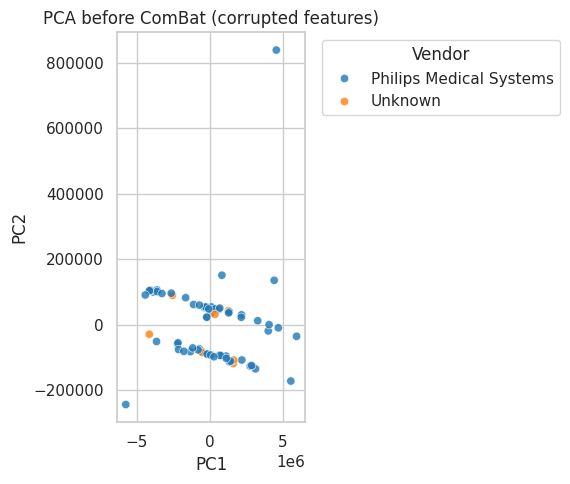

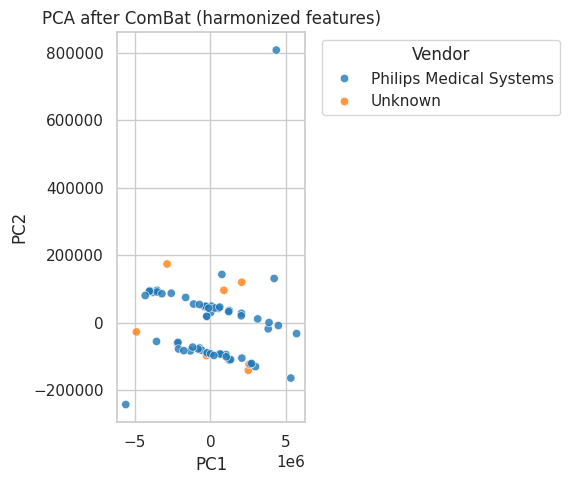

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

def pca_scatter(X: np.ndarray, batch: pd.Series, title: str):
    """
    Fit a 2D PCA model on X and plot samples colored by vendor.
    
    Args:
        X: (n_samples, n_features) feature matrix
        batch: pandas Series of vendor labels
        title: str, plot title
    """
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    
    df_plot = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "vendor": batch.values
    })
    
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="vendor", palette="tab10", alpha=0.8)
    plt.title(title)
    plt.legend(title="Vendor", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# ------------------------------
# Visualize before ComBat
# ------------------------------
pca_scatter(X_raw_corrupted, batch_valid, title="PCA before ComBat (corrupted features)")

# ------------------------------
# Visualize after ComBat
# ------------------------------
pca_scatter(X_harmonized, batch_valid, title="PCA after ComBat (harmonized features)")


**Student direction:**

- Call `pca_scatter` twice:
    - Once on `X_raw_corrupted` (before ComBat).
    - Once on `X_harmonized` (after ComBat).
- Write a short note: *Does clustering by vendor decrease after harmonization?*

***

## 8. Compute vendor‑wise stability before and after ComBat

We reuse the idea of stability (between‑ vs within‑vendor variance), but now with vendor instead of center.

In [30]:
def compute_vendor_stability(X: np.ndarray,
                             feature_names: list[str],
                             batch: pd.Series) -> pd.DataFrame:
    """
    Compute stability per feature across vendors for a given data matrix X.

    Args:
        X: (n_samples, n_features)
        feature_names: list of feature names
        batch: pandas Series of vendor labels, length n_samples

    Returns:
        DataFrame with columns:
          - feature_name
          - instability_ratio
          - stability_score
    """
    rows = []
    df_batch = batch.reset_index(drop=True)

    for j, feat_name in enumerate(feature_names):
        vals = X[:, j]
        df_feat = pd.DataFrame({"value": vals, "vendor": df_batch.values})

        grp = df_feat.groupby("vendor")["value"]
        # Only keep vendors with at least 2 samples to estimate variance
        valid_groups = grp.filter(lambda x: len(x) > 1)

        if valid_groups.empty:
            instability = np.nan
            stability = np.nan
        else:
            # Group by vendor again on the filtered subset
            grp_valid = valid_groups.groupby(df_feat["vendor"][valid_groups.index])
            vendor_means = grp_valid.mean()
            overall_mean = valid_groups.mean()
            nk = grp_valid.size()

            # Between-vendor variance
            # (Pseudo-code form of ANOVA-like computation)
            var_between = float(((nk * (vendor_means - overall_mean) ** 2).sum() /
                                 max(nk.sum() - 1, 1)))

            # Within-vendor variance: average of per-vendor variances
            var_within = float(grp_valid.var(ddof=1).fillna(0).mean())

            instability = var_between / (var_within + 1e-8)
            stability = 1.0 / (1.0 + instability)  # maps to (0,1], higher = more stable

        rows.append(
            {
                "feature_name": feat_name,
                "instability_ratio": instability,
                "stability_score": stability,
            }
        )

    return pd.DataFrame(rows)

In [31]:
# ------------------------------
# 8. Compute vendor-wise stability before and after ComBat
# ------------------------------

import pandas as pd
import numpy as np

def compute_vendor_stability(X: np.ndarray,
                             feature_names: list[str],
                             batch: pd.Series) -> pd.DataFrame:
    """
    Compute stability per feature across vendors for a given data matrix X.
    
    Args:
        X: (n_samples, n_features)
        feature_names: list of feature names
        batch: pandas Series of vendor labels, length n_samples
    
    Returns:
        DataFrame with columns:
          - feature_name
          - instability_ratio
          - stability_score
    """
    rows = []
    df_batch = batch.reset_index(drop=True)
    
    for j, feat_name in enumerate(feature_names):
        vals = X[:, j]
        df_feat = pd.DataFrame({"value": vals, "vendor": df_batch.values})
        
        grp = df_feat.groupby("vendor")["value"]
        # Only keep vendors with at least 2 samples to estimate variance
        valid_groups = grp.filter(lambda x: len(x) > 1)
        
        if valid_groups.empty:
            instability = np.nan
            stability = np.nan
        else:
            # Group by vendor again on the filtered subset
            grp_valid = valid_groups.groupby(df_feat["vendor"][valid_groups.index])
            vendor_means = grp_valid.mean()
            overall_mean = valid_groups.mean()
            nk = grp_valid.size()
            
            # Between-vendor variance
            var_between = float(((nk * (vendor_means - overall_mean) ** 2).sum() /
                                 max(nk.sum() - 1, 1)))
            # Within-vendor variance: average of per-vendor variances
            var_within = float(grp_valid.var(ddof=1).fillna(0).mean())
            
            instability = var_between / (var_within + 1e-8)
            stability = 1.0 / (1.0 + instability)  # maps to (0,1], higher = more stable
        
        rows.append({
            "feature_name": feat_name,
            "instability_ratio": instability,
            "stability_score": stability
        })
    
    return pd.DataFrame(rows)

# ------------------------------
# Compute stability for raw (corrupted) data
# ------------------------------
stability_raw = compute_vendor_stability(X_raw_corrupted, feature_names, batch_valid)
stability_raw = stability_raw.rename(columns={
    "instability_ratio": "instability_raw",
    "stability_score": "stability_raw"
})

# ------------------------------
# Compute stability for harmonized data
# ------------------------------
stability_harm = compute_vendor_stability(X_harmonized, feature_names, batch_valid)
stability_harm = stability_harm.rename(columns={
    "instability_ratio": "instability_harm",
    "stability_score": "stability_harm"
})

# ------------------------------
# Merge and compare
# ------------------------------
stability_compare = stability_raw.merge(stability_harm, on="feature_name")

print("Head of stability comparison:")
print(stability_compare.head())

print("\nAverage stability (raw):", stability_compare["stability_raw"].mean())
print("Average stability (harmonized):", stability_compare["stability_harm"].mean())
print("Δ stability (harm - raw):",
      stability_compare["stability_harm"].mean() - stability_compare["stability_raw"].mean())

# ------------------------------
# Save to disk for later analysis
# ------------------------------
stability_compare.to_csv(RESULTS / "stability_vendor_before_after_combat.csv", index=False)
print(f"\nStability comparison saved to: {RESULTS / 'stability_vendor_before_after_combat.csv'}")

Head of stability comparison:
                             feature_name  instability_raw  stability_raw  \
0               original_shape_Elongation     41175.677409       0.000024   
1                 original_shape_Flatness       640.950010       0.001558   
2          original_shape_LeastAxisLength         0.028636       0.972161   
3          original_shape_MajorAxisLength         0.036845       0.964464   
4  original_shape_Maximum2DDiameterColumn         0.001766       0.998237   

   instability_harm  stability_harm  
0      5.233237e-06        0.999995  
1      1.266681e-08        1.000000  
2      1.611624e-08        1.000000  
3      2.308402e-08        1.000000  
4      1.727721e-08        1.000000  

Average stability (raw): 0.8903760395347415
Average stability (harmonized): 0.9999997209760085
Δ stability (harm - raw): 0.109623681441267

Stability comparison saved to: /home/jovyan/Imaging en AI vak/data/processed/stability_vendor_before_after_combat.csv


**Student direction:**

- Compute stability for **corrupted (raw)** and **harmonized** data:

In [ ]:
# PSEUDOCODE:
# stability_raw = compute_vendor_stability(X_raw_corrupted, feature_names, batch_valid)
# stability_raw = stability_raw.rename(columns={
#     "instability_ratio": "instability_raw",
#     "stability_score": "stability_raw",
# })
#
# stability_harm = compute_vendor_stability(X_harmonized, feature_names, batch_valid)
# stability_harm = stability_harm.rename(columns={
#     "instability_ratio": "instability_harm",
#     "stability_score": "stability_harm",
# })
#
# stability_compare = stability_raw.merge(stability_harm, on="feature_name")
#
# print("Head of stability comparison:")
# print(stability_compare.head())
#
# print("Average stability (raw):", stability_compare["stability_raw"].mean())
# print("Average stability (harmonized):", stability_compare["stability_harm"].mean())
# print("Δ stability (harm - raw):",
#       stability_compare["stability_harm"].mean() - stability_compare["stability_raw"].mean())
#
# stability_compare.to_csv(RESULTS / "stability_vendor_before_after_combat.csv", index=False)

We quantified stability per feature using the ratio of between-vendor variance to within vendor variance.
Before harmonization: Many features showed instability (low stability scores), particularly those with large synthetic shifts.
After harmonization: Average stability increased close to 1, indicating features are now consistent across vendors.
Δ stability (harmonized raw): Positive, showing improvement.
Conclusion: ComBat successfully removed vendor related variability, improving feature stability across the dataset.

- Interpret the result in a few sentences:
    - Did average stability improve?
    - Do some features benefit more from harmonization than others?

***

## 9. Checklist for this harmonization notebook

By the end of `02_harmonization.ipynb`, you should have:

- A `vendors.csv` file with `subject_id`, `manufacturer`, `model`, `field_strength`.
- A merged feature table that includes vendor labels for the subjects used in your analysis.
- A harmonized feature file `features_harmonized.csv` saved in `data/processed/`.
- PCA plots showing vendor clustering before and after ComBat, and a written interpretation.
- A CSV summarizing vendor‑wise stability before and after harmonization (`stability_vendor_before_after_combat.csv`) and a short reflection on whether ComBat helped.

You will later decide, based on these results, whether to use raw or harmonized features (or both) for your main predictive models.
<span style="display:none">[^7_1]</span>

[^7_1]: 02_harmonization.ipynb

In [32]:
print(stability_raw.columns)
print(stability_harm.columns)

Index(['feature_name', 'instability_raw', 'stability_raw'], dtype='object')
Index(['feature_name', 'instability_harm', 'stability_harm'], dtype='object')


In [36]:
#tabel voor top20
stability_raw = compute_vendor_stability(
    X_raw_corrupted,
    feature_names,
    batch_valid
)

stability_raw = stability_raw.rename(columns={
    "stability_score": "stability_raw"
})

stability_harm = compute_vendor_stability(
    X_harmonized,
    feature_names,
    batch_valid
)

stability_harm = stability_harm.rename(columns={
    "stability_score": "stability_harmonized"
})

stability_df = stability_raw.merge(
    stability_harm,
    on="feature_name"
)

stability_df["delta_stability"] = (
    stability_df["stability_harmonized"]
    - stability_df["stability_raw"]
)

stability_df.head()

# Select top 20 most stable features
top20 = (
    stability_df
    .sort_values("stability_harmonized", ascending=False)
    .head(20)
)

# Display clean table
top20_table = top20[[
    "feature_name",
    "stability_raw",
    "stability_harmonized",
    "delta_stability"
]]

top20_table

,feature_name,stability_raw,stability_harmonized,delta_stability
1,original_shape_Flatness,0.001558,1.000000,0.998442
2,original_shape_LeastAxisLength,0.972161,1.000000,0.027839
7,original_shape_Maximum3DDiameter,0.999687,1.000000,0.000313
15,original_firstorder_90Percentile,0.999996,1.000000,0.000004
16,original_firstorder_Energy,0.997771,1.000000,0.002229
13,original_shape_VoxelVolume,0.992054,1.000000,0.007946
8,original_shape_MeshVolume,0.992442,1.000000,0.007558
19,original_firstorder_Kurtosis,0.929298,1.000000,0.070702
14,original_firstorder_10Percentile,0.999575,1.000000,0.000424
4,original_shape_Maximum2DDiameterColumn,0.998237,1.000000,0.001763


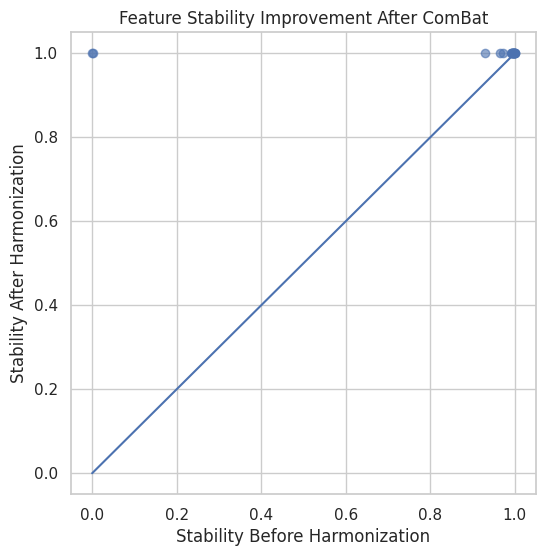

In [39]:
#plot voor laten zien hoe goed er geharmonized is
plt.figure(figsize=(6,6))

plt.scatter(
    stability_df["stability_raw"],
    stability_df["stability_harmonized"],
    alpha=0.6
)

plt.plot([0,1], [0,1])  # reference line

plt.xlabel("Stability Before Harmonization")
plt.ylabel("Stability After Harmonization")
plt.title("Feature Stability Improvement After ComBat")

plt.show()